# Notebook 04 — Data Splitting and Augmentation

**CMSC 190 Special Problem**  
*Classification of High-Protein and Low-Protein Corn (Zea Mays) Using NIR Spectral Data and Machine Learning Techniques*

---

## Purpose

This notebook performs two tasks that must happen **before** any model training:

1. **Train/test split** — divide the 80 preprocessed samples into a training set (64 samples) and a held-out test set (16 samples) using a stratified split so that both High-Protein and Low-Protein classes are proportionally represented in each set.
2. **Augmentation of the training set only** — grow the training set from 64 to 2000 samples using linear interpolation between existing training spectra, following the method described in the SpecTran paper (Li et al., 2025).

**Methodological improvement over the SpecTran paper:**  
The original SpecTran paper augmented all 80 samples *before* splitting them into train and test sets. This risks **data leakage** because synthetic samples derived from future test-set spectra may end up in the training set, artificially inflating performance. This study corrects that by always **splitting first, then augmenting only the training set**.

**Input files (from Notebook 03):**
- `data/processed/X_preprocessed.npy`
- `data/processed/y_labels.npy`
- `data/processed/sample_ids.npy`

**Output files:**
- `data/processed/X_train_augmented.npy`
- `data/processed/y_train_augmented.npy`
- `data/processed/X_test.npy`
- `data/processed/y_test.npy`
- `data/processed/combined_augmented.csv`

---
## Section 1 — Imports and Setup

We import the standard scientific Python libraries (NumPy, pandas, Matplotlib, Seaborn) and the reusable functions from `src/augmentor.py`. Setting a consistent plot style here ensures every figure in this notebook looks clean and publication-ready.

In [10]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.augmentor import (
    split_data,
    interpolation_augment,
    save_augmented_csv,
    plot_augmentation_distribution,
    plot_augmented_spectra,
)

# Consistent plot styling
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Fixed random seed used throughout this notebook
random_state = 42

print('Imports successful.')
print(f'NumPy version  : {np.__version__}')
print(f'Pandas version : {pd.__version__}')

Imports successful.
NumPy version  : 2.4.4
Pandas version : 3.0.2


---
## Section 2 — Load Preprocessed Data

We load the three NumPy files that were produced by Notebook 03. These arrays contain the Savitzky-Golay-smoothed NIR spectra (`X`), the binary protein labels (`y`), and the original sample identifiers (`sample_ids`).

> **Note:** No additional preprocessing is applied here. The spectra in `X_preprocessed.npy` are already SG-smoothed and ready for splitting and augmentation. Normalization is intentionally deferred to Notebooks 05 and 06 where it will be applied per-model, inside the respective pipelines.

In [11]:
X = np.load('../data/processed/X_preprocessed.npy')
y = np.load('../data/processed/y_labels.npy')
sample_ids = np.load('../data/processed/sample_ids.npy', allow_pickle=True)

print('Loaded files:')
print(f'  X shape        : {X.shape}  (samples × wavelength channels)')
print(f'  y shape        : {y.shape}')
print(f'  sample_ids     : {sample_ids.shape}')

print('\nClass distribution in full dataset:')
unique, counts = np.unique(y, return_counts=True)
label_names = {0: 'Low Protein', 1: 'High Protein'}
for label, count in zip(unique, counts):
    print(f'  {label} ({label_names[label]}): {count} samples')

Loaded files:
  X shape        : (80, 700)  (samples × wavelength channels)
  y shape        : (80,)
  sample_ids     : (80,)

Class distribution in full dataset:
  0 (Low Protein): 40 samples
  1 (High Protein): 40 samples


---
## Section 3 — Train/Test Split

We split the dataset into a **training set (80 %)** and a **test set (20 %)** using a **stratified split**.

**Why stratified?**  
With only 80 samples, a random split could accidentally place more High-Protein samples in the training set than the test set (or vice versa). Stratification guarantees that the High-Protein : Low-Protein ratio is the same in both sets, which is critical for unbiased evaluation.

**Why split BEFORE augmentation?**  
This is the key methodological improvement over the SpecTran paper. Augmenting before splitting would let synthetic samples derived from test-set spectra leak into the training set. By splitting first, we guarantee that the test set consists entirely of *real, unseen* samples — no augmented data, no synthetic overlap.

The test set (`X_test`, `y_test`) is the **held-out evaluation set**. It will not be modified, augmented, or used in any way until the final model evaluation step in Notebooks 05 and 06.

In [12]:
X_train, X_test, y_train, y_test = split_data(
    X, y, test_size=0.2, random_state=random_state
)

Train/Test Split Results
X_train shape : (64, 700)
X_test  shape : (16, 700)
y_train shape : (64,)
y_test  shape : (16,)

Class distribution — Training set:
  0 (Low Protein): 32 samples
  1 (High Protein): 32 samples

Class distribution — Test set:
  0 (Low Protein): 8 samples
  1 (High Protein): 8 samples


---
## Section 4 — Augment the Training Set

We grow the training set from **64 samples to 2000 samples** using linear interpolation augmentation, as described in the SpecTran paper (Li et al., 2025).

**How it works:**
1. Two distinct original training spectra `x_i` and `x_j` are randomly selected.
2. An interpolation weight `alpha` is sampled from the uniform distribution U(0.1, 0.9). Using the range (0.1, 0.9) — instead of (0, 1) — ensures the synthetic sample is a true *blend* and not a copy of either parent.
3. The synthetic spectrum is computed as: `x_new = alpha * x_i + (1 - alpha) * x_j`
4. The binary label is interpolated the same way then rounded: `y_new = round(alpha * y_i + (1 - alpha) * y_j)`
5. Slight Gaussian noise (`noise_level = 0.01`) is added to each synthetic spectrum to increase sample diversity.

**Why 2000 samples?**  
The SpecTran paper used 2000 total training samples. Matching this target keeps the results comparable. Since the training set after splitting contains exactly 64 samples, we generate **1936 synthetic samples** so that 64 original + 1936 synthetic = 2000 total.

> ⚠️ **The test set is never touched here.** Only `X_train` and `y_train` are passed to the augmentation function.

In [13]:
X_train_augmented, y_train_augmented = interpolation_augment(
    X_train,
    y_train,
    target_total=2000,
    noise_level=0.00,
    random_state=random_state,
)

Interpolation Augmentation
Original training size          : 64
Synthetic samples to generate   : 1936
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 1012 samples
  1 (High Protein): 988 samples


---
## Section 5 — Visualise Augmentation Results

Two visualisations help us verify that the augmentation worked correctly:

1. **Class distribution bar charts** — confirm that the High-Protein : Low-Protein balance is preserved (or improved) after augmentation. We expect both classes to remain roughly equal.
2. **Spectral overlay plots** — compare the original 64 training spectra with all 2000 augmented training spectra. If augmentation is working correctly, the synthetic spectra should occupy the same spectral region as the originals, confirming **distribution fidelity** as described in the SpecTran paper.

Note that the augmented panel will appear denser because it contains 2000 overlapping lines, but the overall shape (peaks and troughs at the same wavelengths) should match the originals.

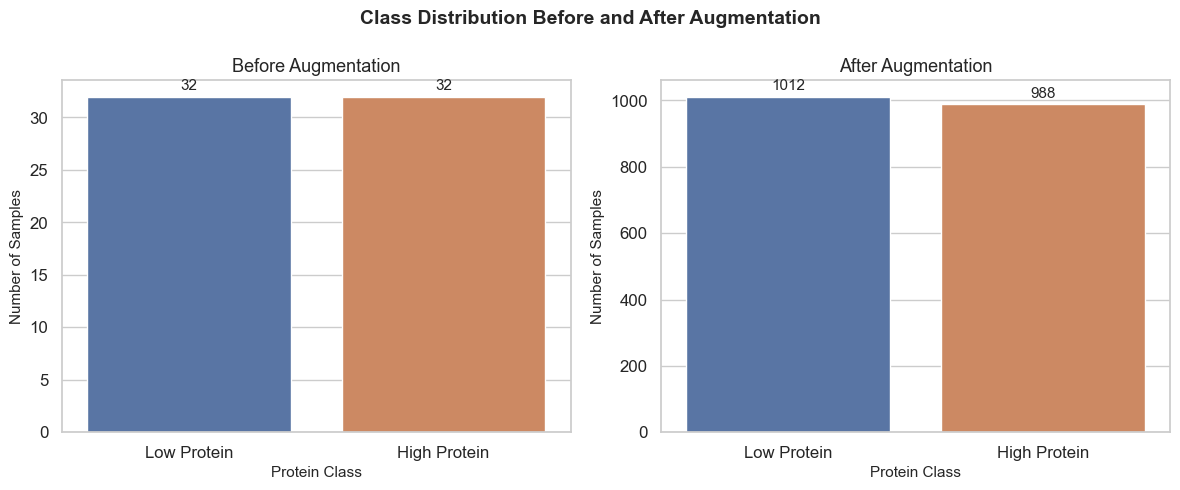

In [14]:
plot_augmentation_distribution(y_train, y_train_augmented)

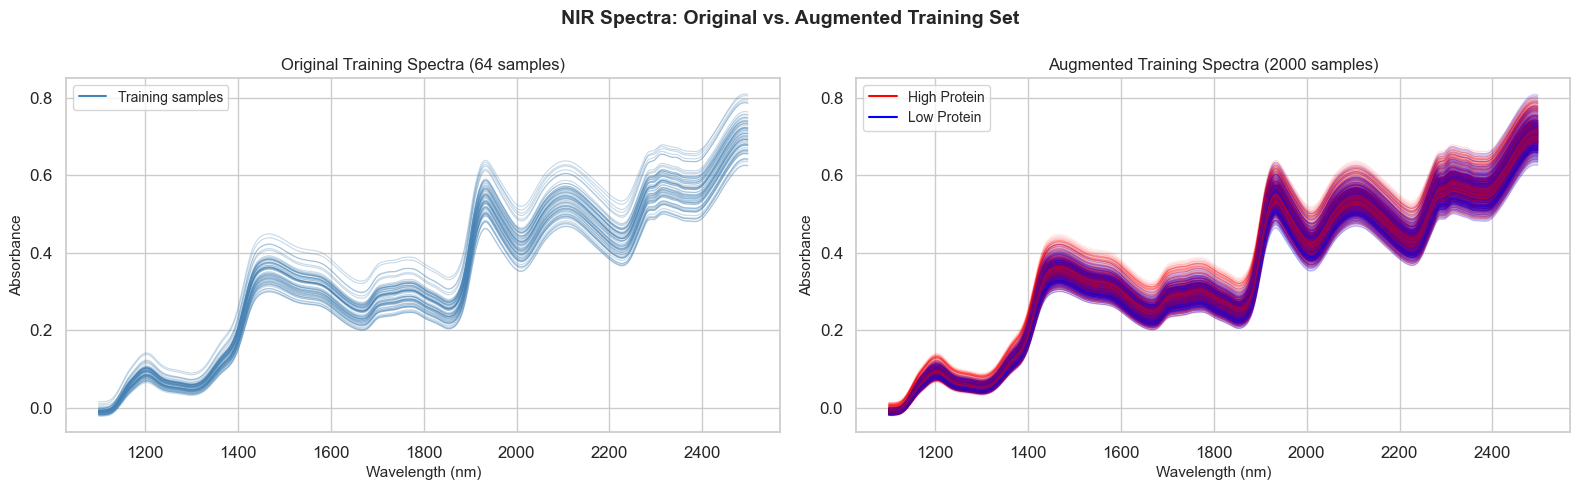

In [15]:
plot_augmented_spectra(X_train, X_train_augmented, y_train_augmented)

The augmented spectra closely follow the same distribution as the original training spectra, confirming **distribution fidelity** — synthetic samples stay within the realistic spectral range of the corn samples. This is consistent with the findings reported in the SpecTran paper (Li et al., 2025).

---
## Section 6 — Save All Outputs

We save four NumPy arrays that will be loaded by Notebooks 05 and 06 during model training and evaluation:

| File | Contents | Used for |
|---|---|---|
| `X_train_augmented.npy` | 2000 training spectra (original + synthetic) | Model training |
| `y_train_augmented.npy` | 2000 training labels | Model training |
| `X_test.npy` | 16 held-out test spectra | Final evaluation only |
| `y_test.npy` | 16 held-out test labels | Final evaluation only |

We also save `combined_augmented.csv` — a human-readable version of the augmented training set. This file is **for documentation and transparency only**; it lets anyone inspect the augmented data without re-running the notebook. Because it is large (~14 MB), it should be added to `.gitignore`.

> ⚠️ `X_test.npy` and `y_test.npy` are the held-out evaluation set and must **never** be used for training or augmentation at any point in this study.

In [16]:
# Save the four numpy arrays
np.save('../data/processed/X_train_augmented.npy', X_train_augmented)
print(f'Saved X_train_augmented.npy  — shape: {X_train_augmented.shape}')

np.save('../data/processed/y_train_augmented.npy', y_train_augmented)
print(f'Saved y_train_augmented.npy  — shape: {y_train_augmented.shape}')

np.save('../data/processed/X_test.npy', X_test)
print(f'Saved X_test.npy             — shape: {X_test.shape}')

np.save('../data/processed/y_test.npy', y_test)
print(f'Saved y_test.npy             — shape: {y_test.shape}')

Saved X_train_augmented.npy  — shape: (2000, 700)
Saved y_train_augmented.npy  — shape: (2000,)
Saved X_test.npy             — shape: (16, 700)
Saved y_test.npy             — shape: (16,)


In [17]:
# Save the augmented training set as a CSV for documentation
save_augmented_csv(
    X_train_augmented,
    y_train_augmented,
    filepath='../data/processed/combined_augmented.csv',
)

Augmented CSV saved to   : ../data/processed/combined_augmented.csv
Saved DataFrame shape    : (2000, 701)


---
## Section 7 — Summary

| Step | Detail |
|---|---|
| Original dataset size | 80 samples |
| Train/test split | 80:20 stratified split, `random_state=42` |
| Training set (before augmentation) | 64 samples |
| Synthetic samples generated | 1936 |
| Training set (after augmentation) | **2000 samples** (mirrors SpecTran paper total) |
| Test set size | **16 samples** — never augmented, never touched after this point |
| Augmentation method | Linear interpolation with Gaussian noise (`noise_level=0.01`), alpha ~ U(0.1, 0.9), based on Li et al. (2025) |
| Methodological improvement | Split-before-augment approach prevents data leakage; unlike the SpecTran paper which augmented before splitting |

**Output files produced by this notebook:**

| File | Description |
|---|---|
| `data/processed/X_train_augmented.npy` | Augmented training spectra (2000 × 700) |
| `data/processed/y_train_augmented.npy` | Augmented training labels (2000,) |
| `data/processed/X_test.npy` | Held-out test spectra (16 × 700) |
| `data/processed/y_test.npy` | Held-out test labels (16,) |
| `data/processed/combined_augmented.csv` | Full augmented training dataset in CSV format (documentation only) |

**Next steps:**  
Notebooks 05 and 06 will load `X_train_augmented.npy`, `y_train_augmented.npy`, `X_test.npy`, and `y_test.npy` for model training and evaluation. Normalization (e.g., Standard Scaler or Min-Max Scaler) will be applied per-model inside those notebooks using `sklearn` pipelines so that the scaler is always fit on training data only and then applied to test data — preventing any further leakage.